# Retail Sales Prediction using Machine Learning !!!

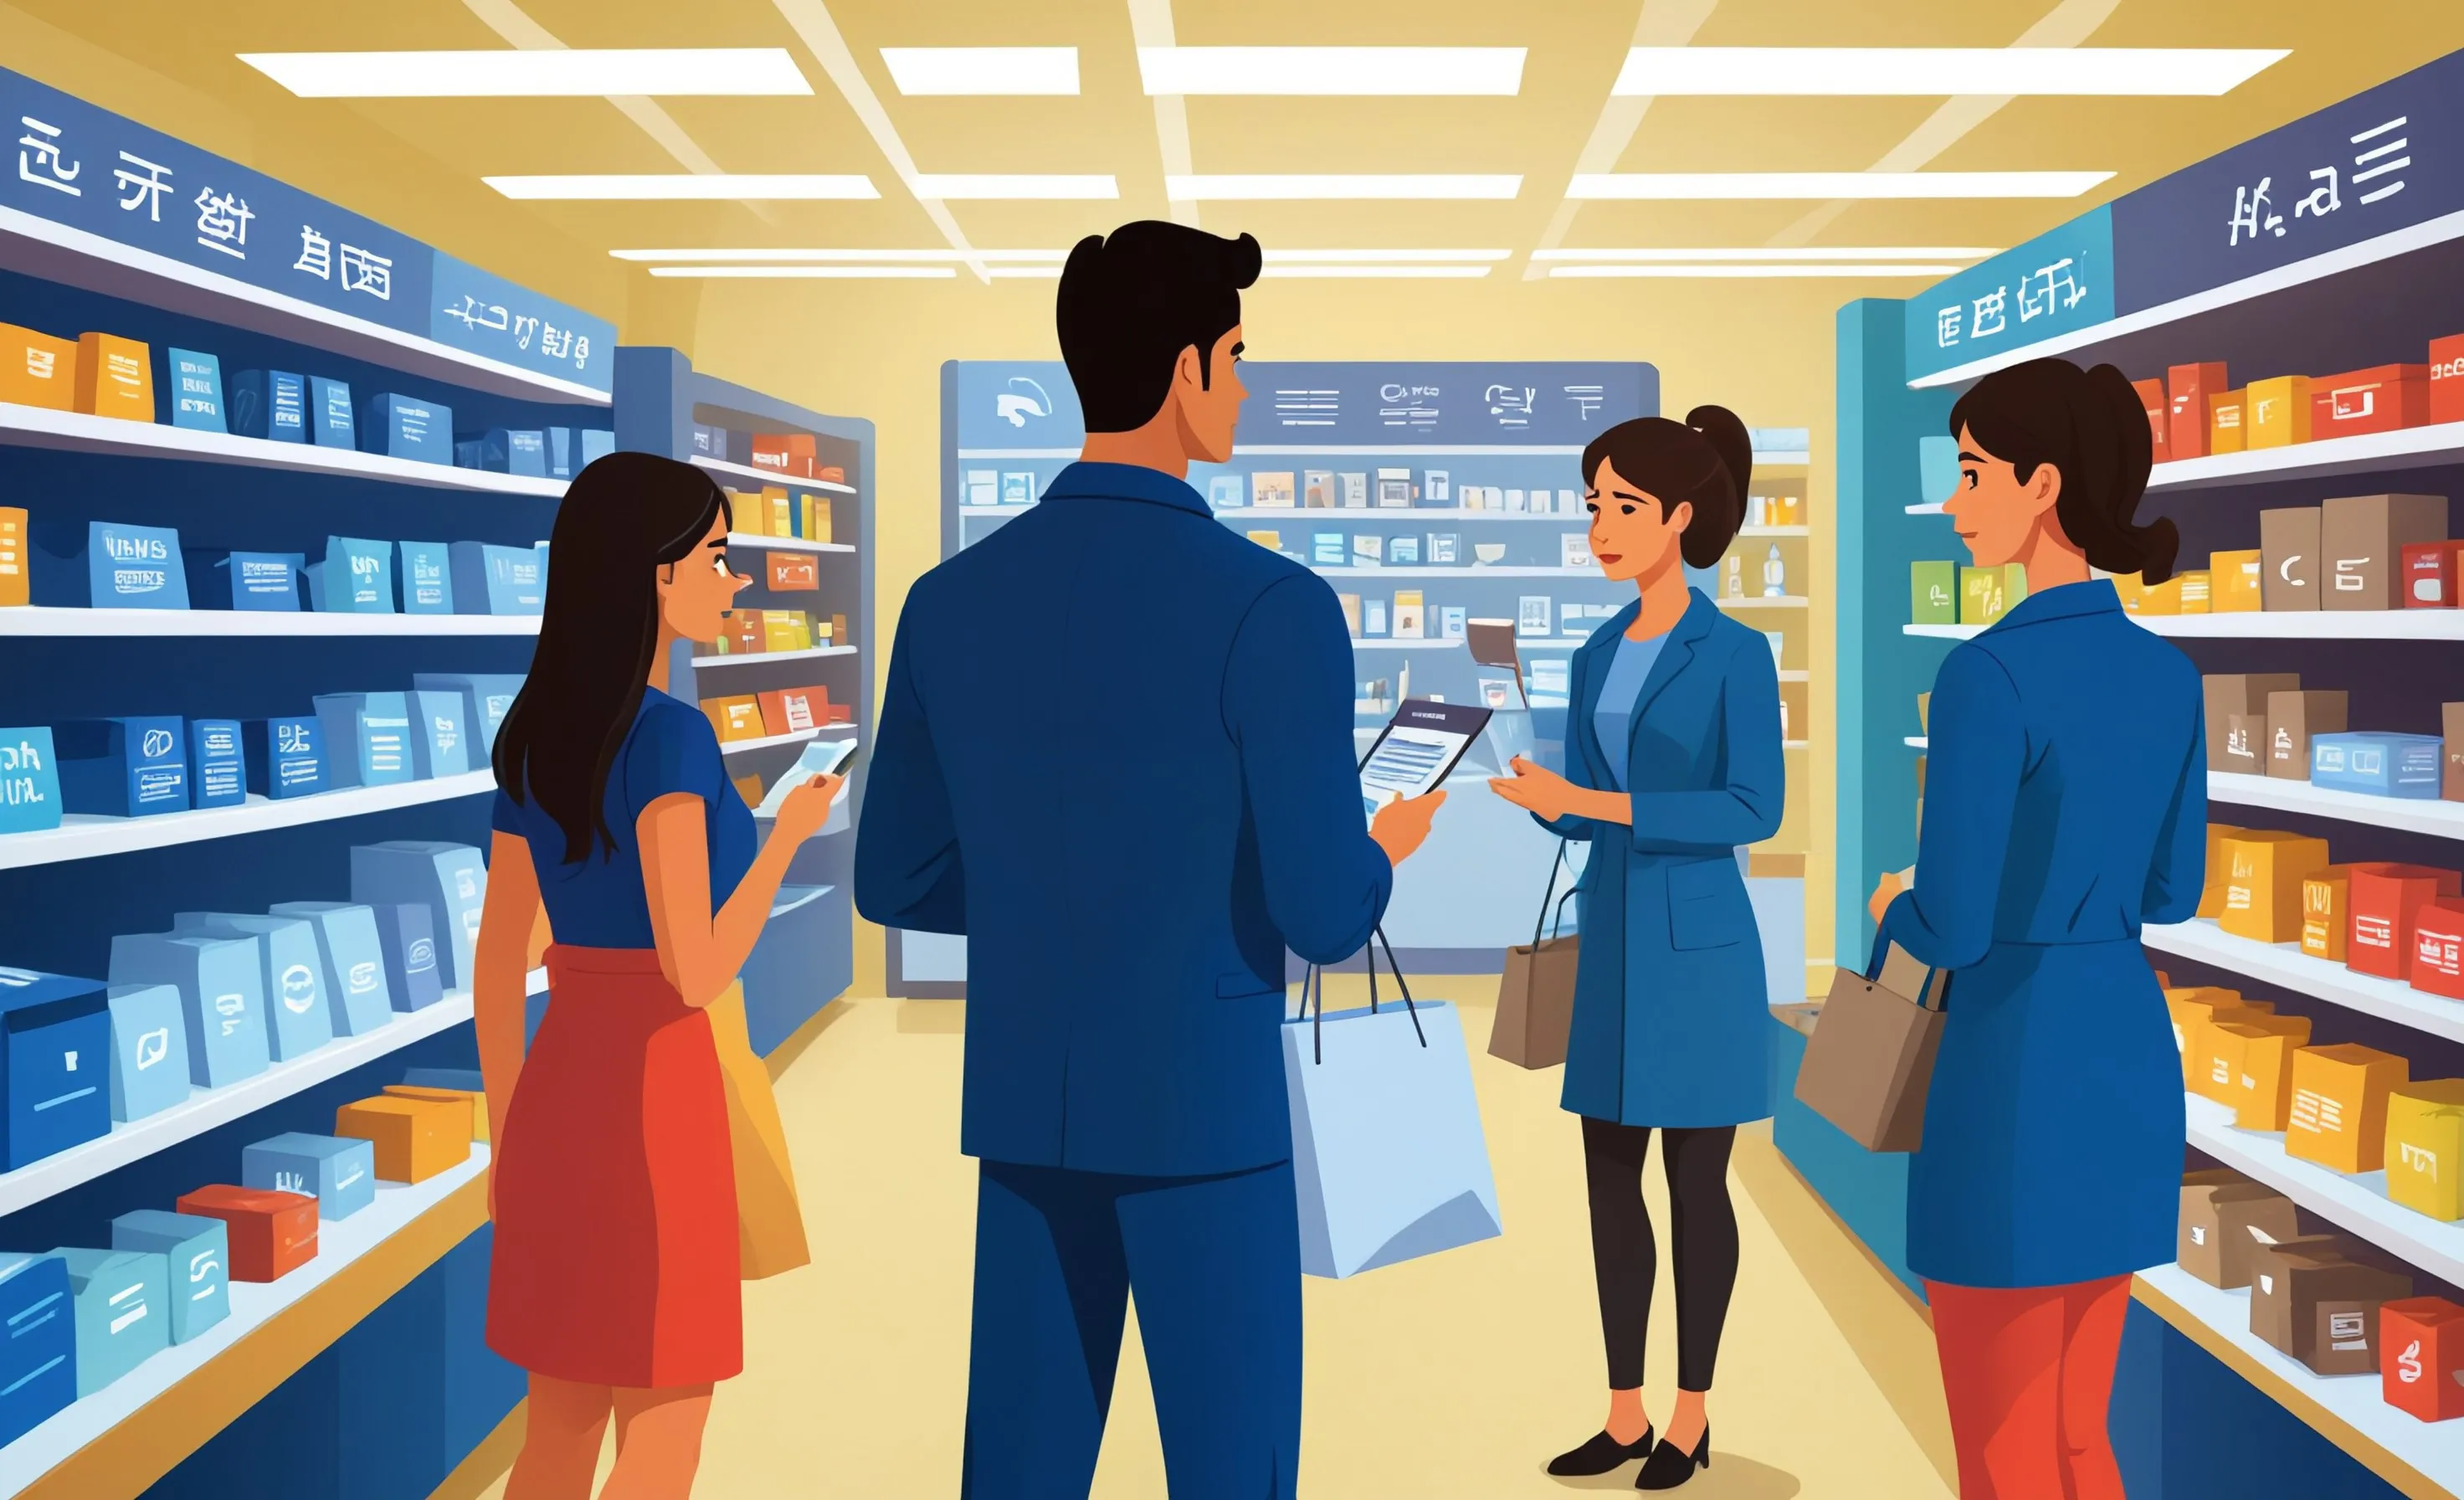

Problem Statement
The retail and warehouse data provided contains sales and transfer information across different suppliers, items, and time periods (months and years). The goal of the problem might be:

Sales Forecasting: Predict future sales (retail or warehouse) based on historical data. This is a Time Series Forecasting problem.

Demand Prediction: Estimate the demand for items based on the available sales and transfer data to optimize inventory management.

Supplier-Item Analysis: Identify patterns and trends in supplier performance, specific item sales, and warehouse transfers to improve logistics or retail strategies.

Sales Transfer Prediction: Predict how items are transferred between retail and warehouse locations to balance inventory levels.
Depending on the specific goal, different models and techniques like time series forecasting, regression, or even classification (for items at risk of running out of stock) might be used.

Variable:

YEAR:
Type: Categorical (or could be continuous depending on use)
Description: The year in which the data was recorded.
ML Perspective: It can be used for temporal analysis or as a time feature in forecasting.

MONTH:
Type: Categorical
Description: The month in which the data was recorded (e.g., January, February).
ML Perspective: Another temporal feature, typically used in combination with the year for seasonality detection in sales.

SUPPLIER:
Type: Categorical
Description: The supplier providing the product.
ML Perspective: Can be used to determine supplier performance or to cluster items based on supplier contribution.

ITEM CODE:
Type: Categorical
Description: Unique identifier for each item/product.
ML Perspective: Acts as a key or identifier for individual items, useful in item-specific modeling or clustering.

ITEM DESCRIPTION:
Type: Categorical
Description: The descriptive name of the item/product.
ML Perspective: This feature might be irrelevant for modeling as it could be redundant with the ITEM CODE, unless NLP techniques are applied for item classification or extraction of useful information.

ITEM TYPE:
Type: Categorical
Description: Type or category of the item (e.g., electronics, clothing, food).
ML Perspective: Important for categorical encoding and for determining different sales patterns across item types.

RETAIL SALES (RETAIL SA):
Type: Continuous
Description: The total retail sales for the specific item.
ML Perspective: This is a key feature for predictive models, especially in sales forecasting.

RETAIL TRANSFERS (RETAIL TR):
Type: Continuous
Description: The quantity of items transferred between retail locations.
ML Perspective: Useful for predicting transfer needs or optimizing inventory balancing between stores.

WAREHOUSE SALES:
Type: Continuous
Description: The total sales from warehouse inventory.
ML Perspective: Useful in understanding how much of the stock is sold directly from the warehouse, which could be compared with retail sales for demand planning.

Potential ML Tasks
Predicting retail or warehouse sales: Based on item, supplier, and temporal data.
Classifying items with high transfer rates: To manage inventory effectively.
Time Series Analysis: To identify trends, seasonality, and forecast future sales.

These features allow us to solve multiple ML problems such as forecasting, classification, or clustering depending on business needs.

In [1]:
# importing basic libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.getcwd()

'C:\\Users\\soura\\Downloads\\Retail analysis project'

In [3]:
df = pd.read_csv(r"C:/Users/soura/Downloads/Retail analysis project/retail_warehouse_data.csv")
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [4]:
df.shape

(30000, 9)

In [5]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [6]:
df.duplicated().sum()

0

In [7]:
# df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum()

YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          29967 non-null  object 
 3   ITEM CODE         30000 non-null  object 
 4   ITEM DESCRIPTION  30000 non-null  object 
 5   ITEM TYPE         30000 non-null  object 
 6   RETAIL SALES      29999 non-null  float64
 7   RETAIL TRANSFERS  30000 non-null  float64
 8   WAREHOUSE SALES   30000 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.1+ MB


In [10]:
df.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,30000.0,30000.000000,29999.000000,30000.000000,30000.000000
mean,2020.0,3.911467,6.939796,6.594058,27.431031
std,0.0,2.836788,33.081054,27.879428,272.166085
min,2020.0,1.000000,-0.420000,-6.000000,-3999.000000
25%,2020.0,1.000000,0.000000,0.000000,0.000000
50%,2020.0,3.000000,0.160000,0.000000,1.000000
75%,2020.0,7.000000,2.920000,3.000000,6.000000
max,2020.0,9.000000,2739.000000,1507.000000,18317.000000


<Axes: ylabel='RETAIL SALES'>

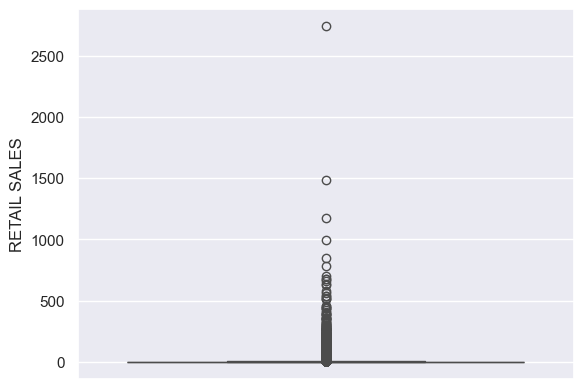

In [11]:
sns.boxplot(y='RETAIL SALES', data=df)

In [12]:
df.nunique()

YEAR                    1
MONTH                   4
SUPPLIER              290
ITEM CODE           15668
ITEM DESCRIPTION    15732
ITEM TYPE               8
RETAIL SALES         3657
RETAIL TRANSFERS      542
WAREHOUSE SALES      1032
dtype: int64

In [13]:
median_value = df['RETAIL SALES'].median()
median_value

0.16

In [14]:
df['RETAIL SALES'].fillna(median_value, inplace=True)

In [15]:
df.isnull().sum()/len(df)*100

YEAR                0.00
MONTH               0.00
SUPPLIER            0.11
ITEM CODE           0.00
ITEM DESCRIPTION    0.00
ITEM TYPE           0.00
RETAIL SALES        0.00
RETAIL TRANSFERS    0.00
WAREHOUSE SALES     0.00
dtype: float64

In [16]:
df.head(3)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.0,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.0,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.0,0.0,1.0


In [17]:
df['SUPPLIER'].fillna('UNKNOWN', inplace=True)

In [18]:
df.isnull().sum()/len(df)*100

YEAR                0.0
MONTH               0.0
SUPPLIER            0.0
ITEM CODE           0.0
ITEM DESCRIPTION    0.0
ITEM TYPE           0.0
RETAIL SALES        0.0
RETAIL TRANSFERS    0.0
WAREHOUSE SALES     0.0
dtype: float64

In [19]:
len(df)

30000

In [20]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type Columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64','float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type Columns:
Index(['SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE'], dtype='object')

Numerical type columns:
Index(['YEAR', 'MONTH', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'], dtype='object')


In [21]:
df.select_dtypes(include=['int64','float64']).columns

Index(['YEAR', 'MONTH', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'], dtype='object')

In [22]:
object_columns

Index(['SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE'], dtype='object')

In [23]:
df.nunique()

YEAR                    1
MONTH                   4
SUPPLIER              291
ITEM CODE           15668
ITEM DESCRIPTION    15732
ITEM TYPE               8
RETAIL SALES         3657
RETAIL TRANSFERS      542
WAREHOUSE SALES      1032
dtype: int64

In [24]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [25]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64','float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)
    return categorical_features, non_categorical_features, discrete_features, continuous_features
        
    

In [26]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [27]:
print("categorical_features :", categorical)
print("non_categorical_features :", non_categorical)
print("discrete_features :", discrete)
print("continuous_features :", continuous)

categorical_features : ['ITEM TYPE']
non_categorical_features : ['SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION']
discrete_features : ['YEAR', 'MONTH']
continuous_features : ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']


In [28]:
for i in categorical:
    print(i)
    print(df[i].unique())
    print()

ITEM TYPE
['WINE' 'BEER' 'LIQUOR' 'STR_SUPPLIES' 'KEGS' 'REF' 'DUNNAGE'
 'NON-ALCOHOL']



In [29]:
for i in categorical:
    print(i)
    print(df[i].value_counts())
    print()

ITEM TYPE
ITEM TYPE
WINE            18680
LIQUOR           5995
BEER             4217
KEGS              808
NON-ALCOHOL       216
STR_SUPPLIES       63
DUNNAGE            13
REF                 8
Name: count, dtype: int64



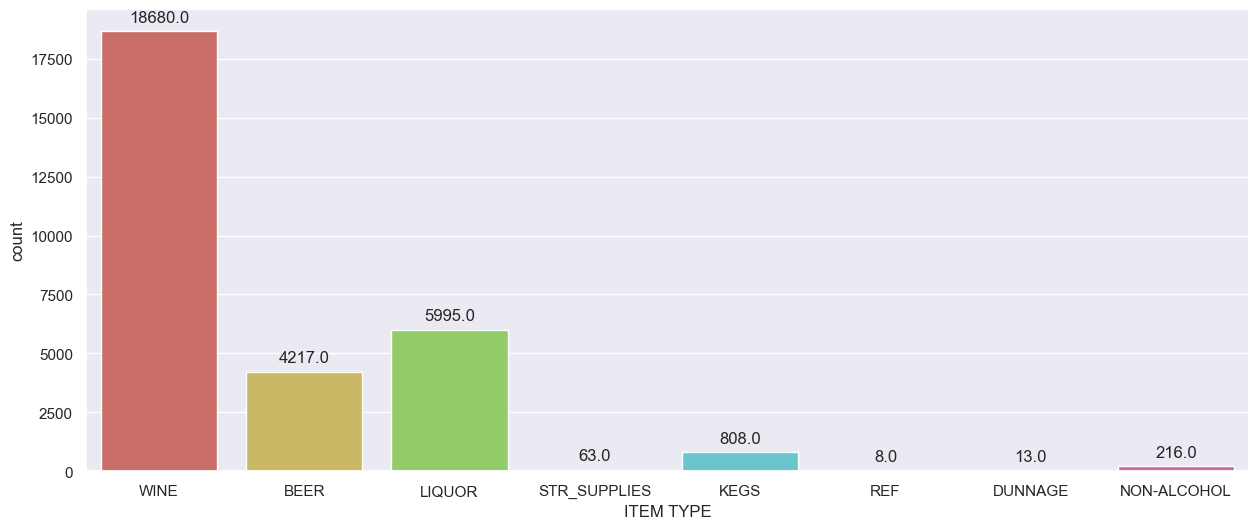

In [30]:
for i in categorical:
    plt.figure(figsize=(15,6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', xy =(p.get_x() + p.get_width() / 2., height), xytext=(0,10),
                    textcoords='offset points', ha ='center', va='center')

    
        
    plt.show()

In [31]:
import plotly.express as px

for i in categorical:
    counts = df[i].value_counts()
    fig = px.pie(counts, values=counts.values, names=counts.index, title=f'Distribution of {i}')
    fig.show()

In [32]:
for i in discrete:
    print(i)
    print(df[i].unique())
    print()

YEAR
[2020]

MONTH
[1 7 3 9]



In [33]:
for i in discrete:
    print(i)
    print(df[i].value_counts())
    print()

YEAR
YEAR
2020    30000
Name: count, dtype: int64

MONTH
MONTH
1    11987
7    11190
3     5730
9     1093
Name: count, dtype: int64



In [34]:
for i in discrete:
    counts = df[i].value_counts()
    fig = px.pie(counts, values=counts.values, names=counts.index, title=f'Distribution of {i}')
    fig.show()

In [35]:
continuous

['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

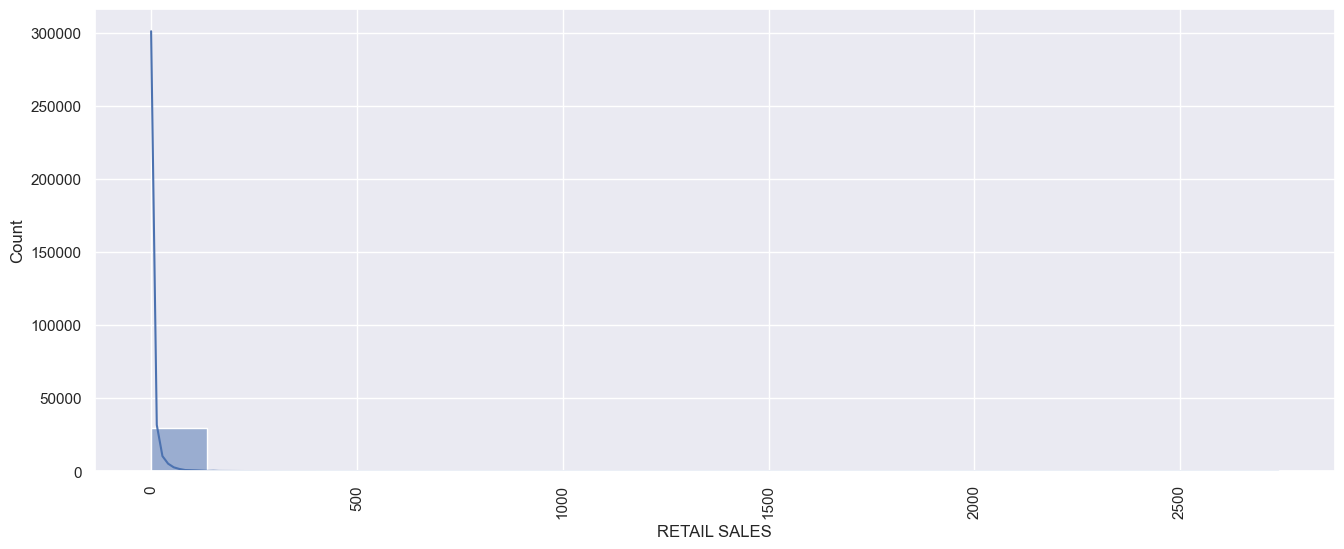

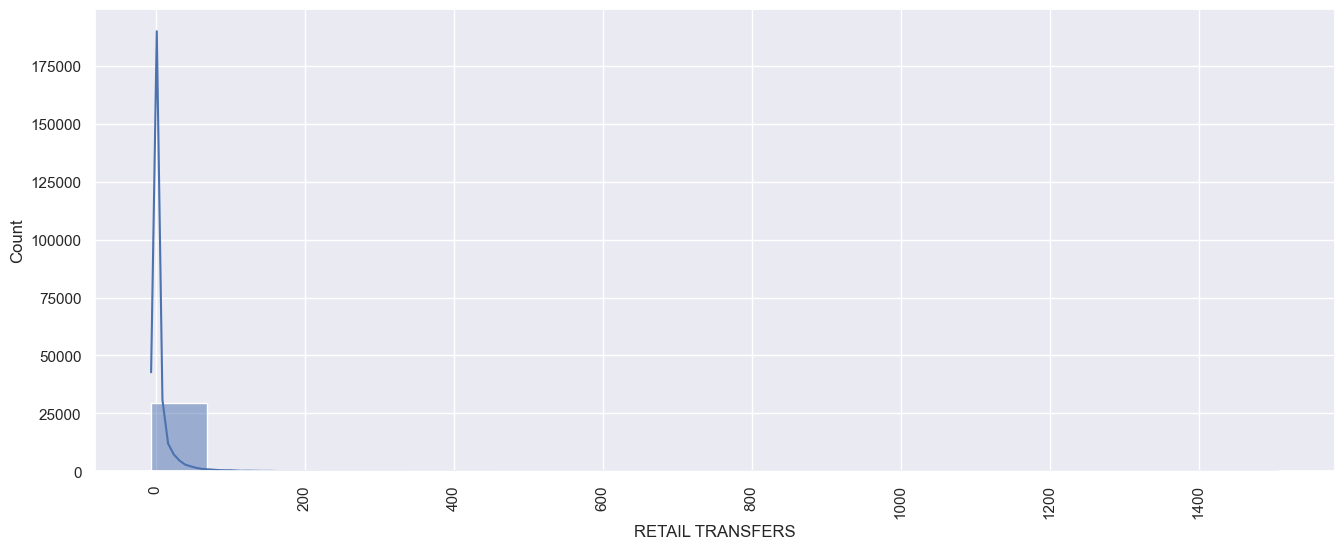

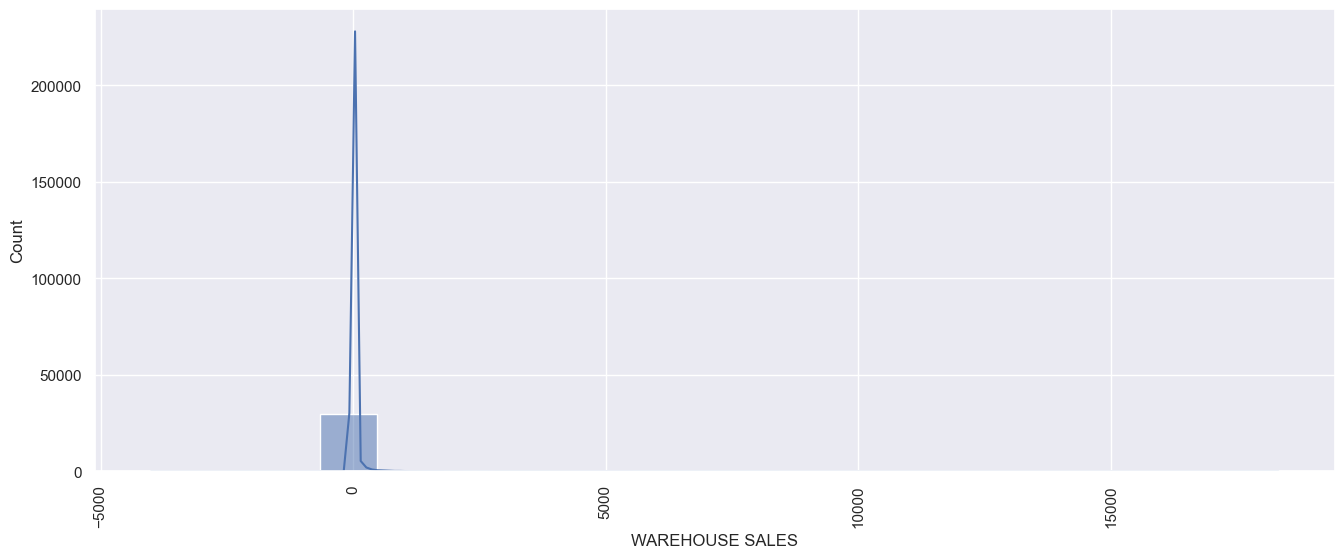

In [36]:
for i in continuous:
    plt.figure(figsize=(16,6))
    sns.histplot(df[i], bins = 20, kde = True, palette ='hls')
    plt.xticks(rotation = 90)
    plt.show()

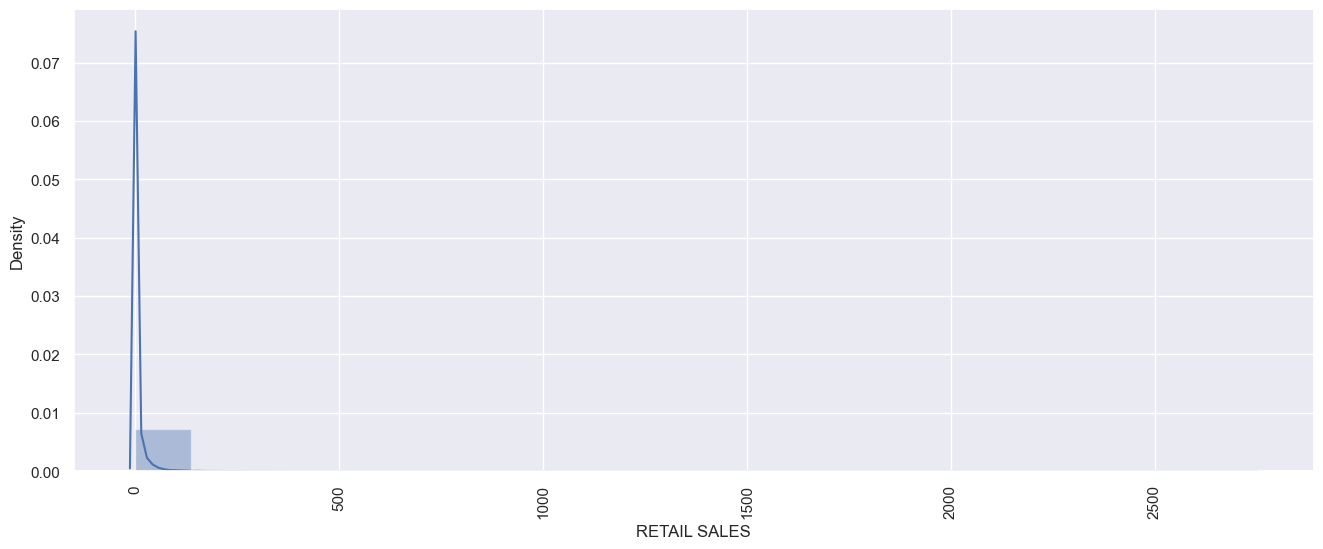

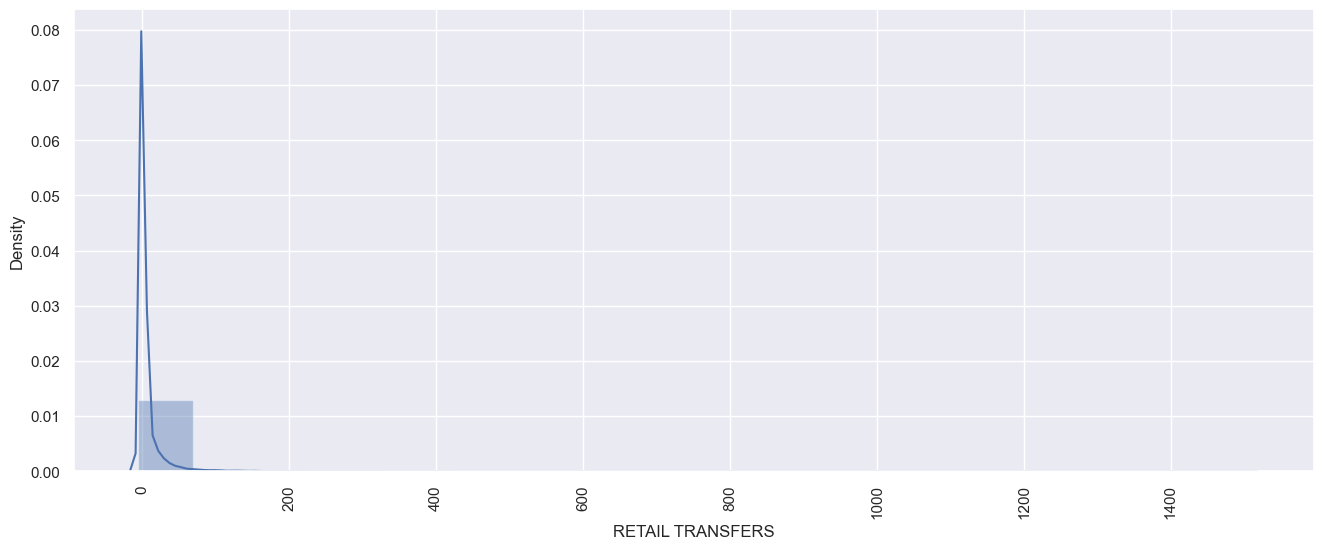

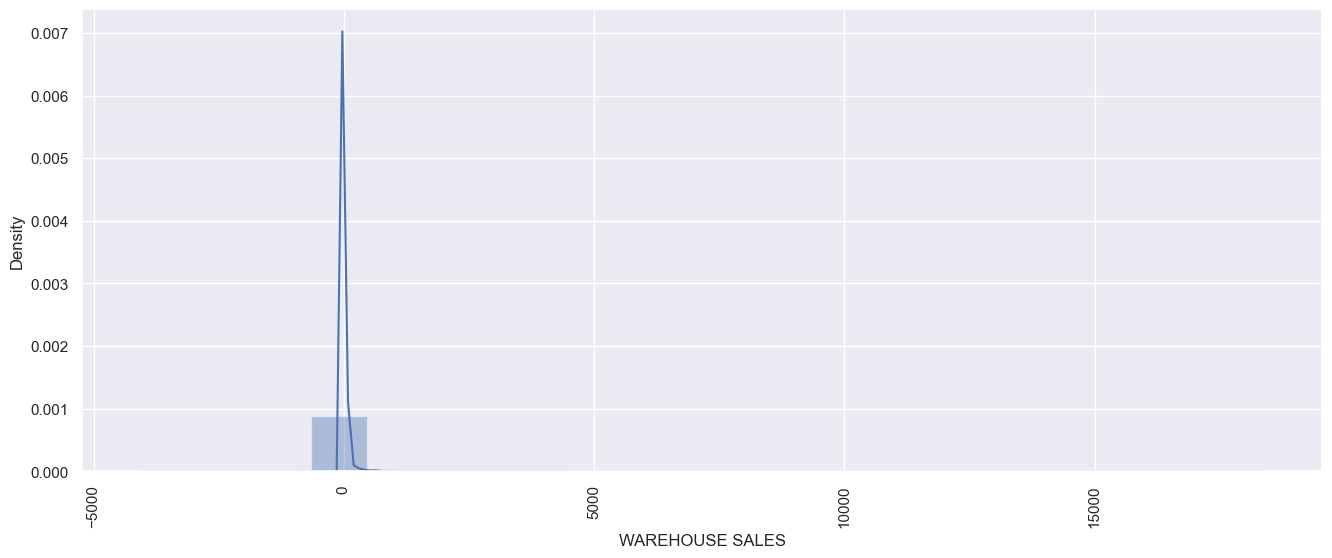

In [37]:
for i in continuous:
    plt.figure(figsize=(16,6))
    sns.distplot(df[i], bins = 20, kde = True)
    plt.xticks(rotation = 90)
    plt.show()

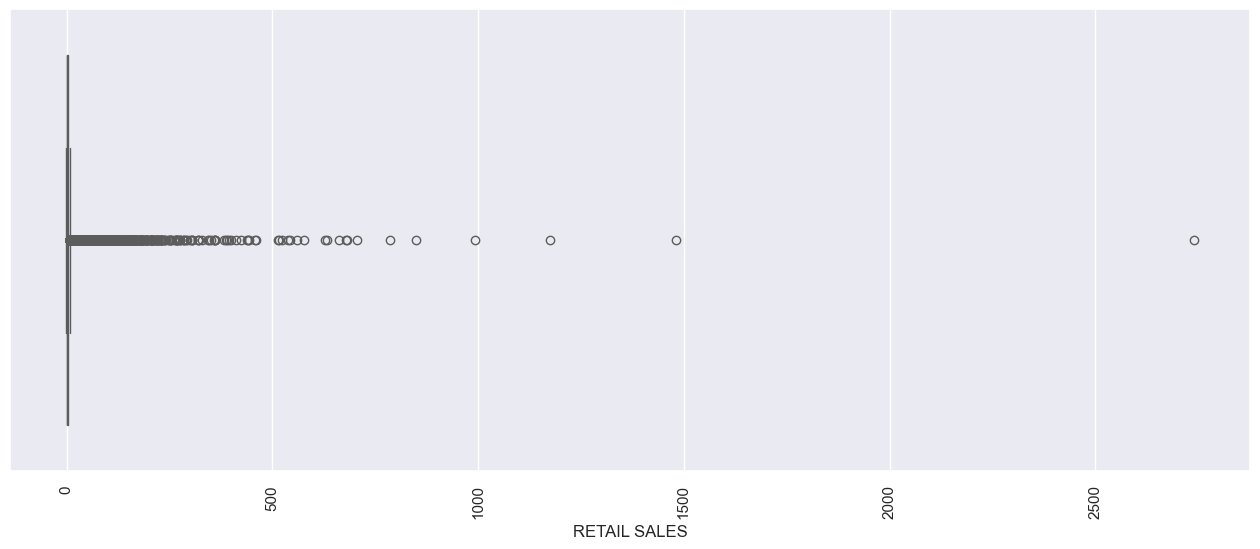

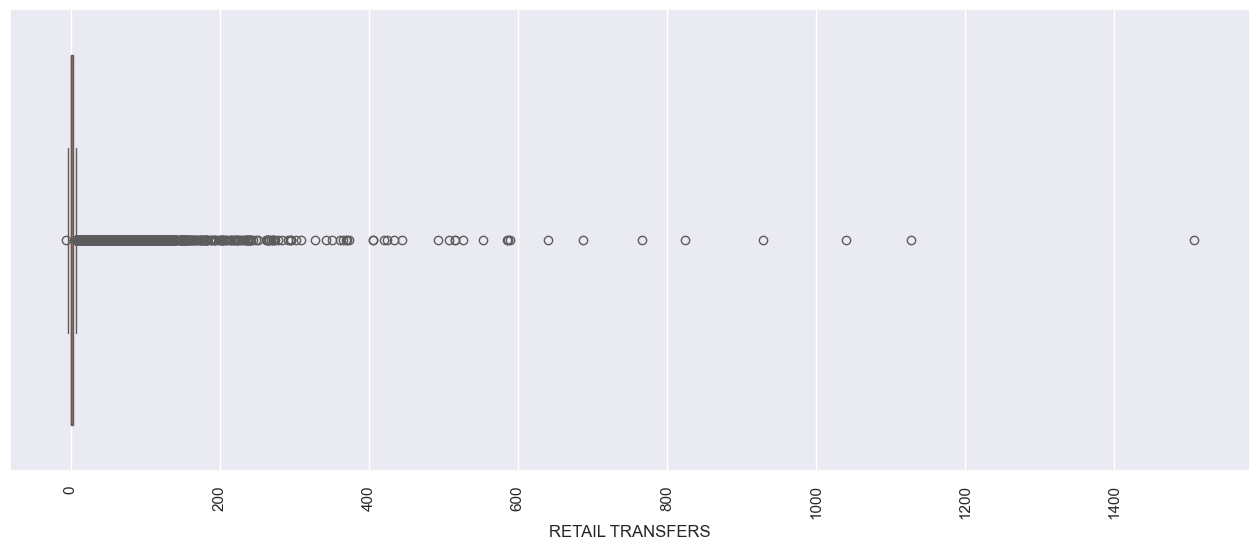

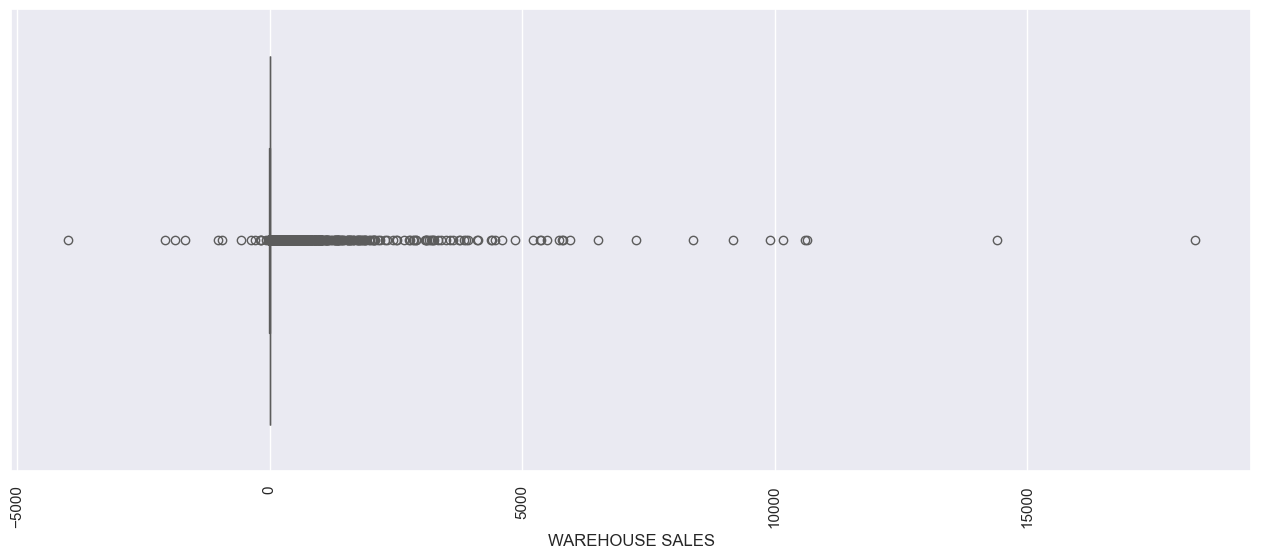

In [38]:
for i in continuous:
    plt.figure(figsize=(16,6))
    sns.boxplot(x=i, data=df, palette='hls')
    plt.xticks(rotation = 90)
    plt.show()

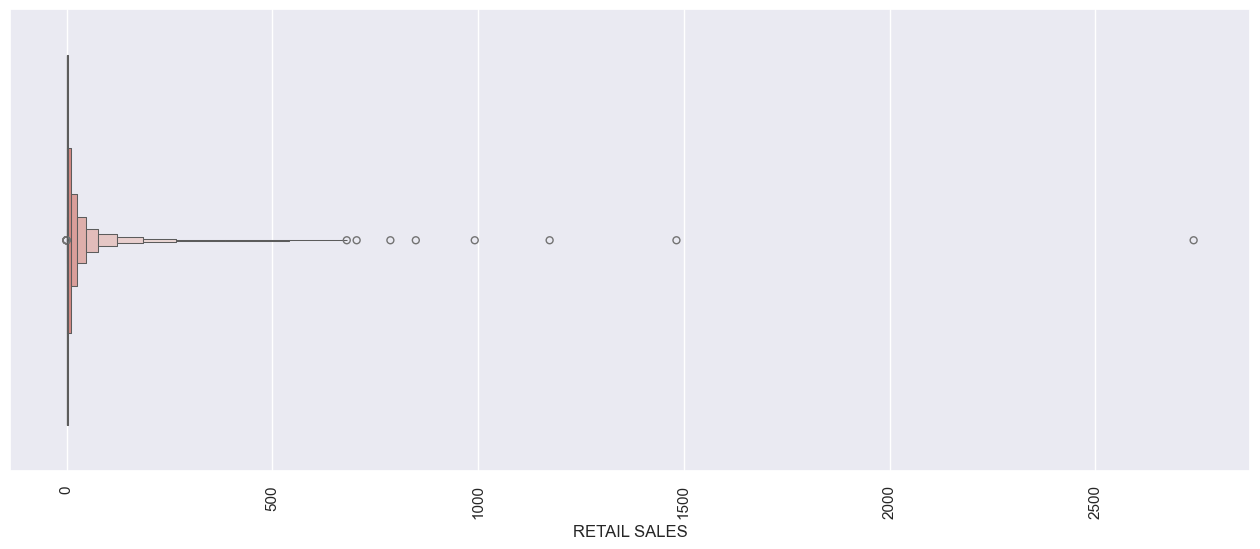

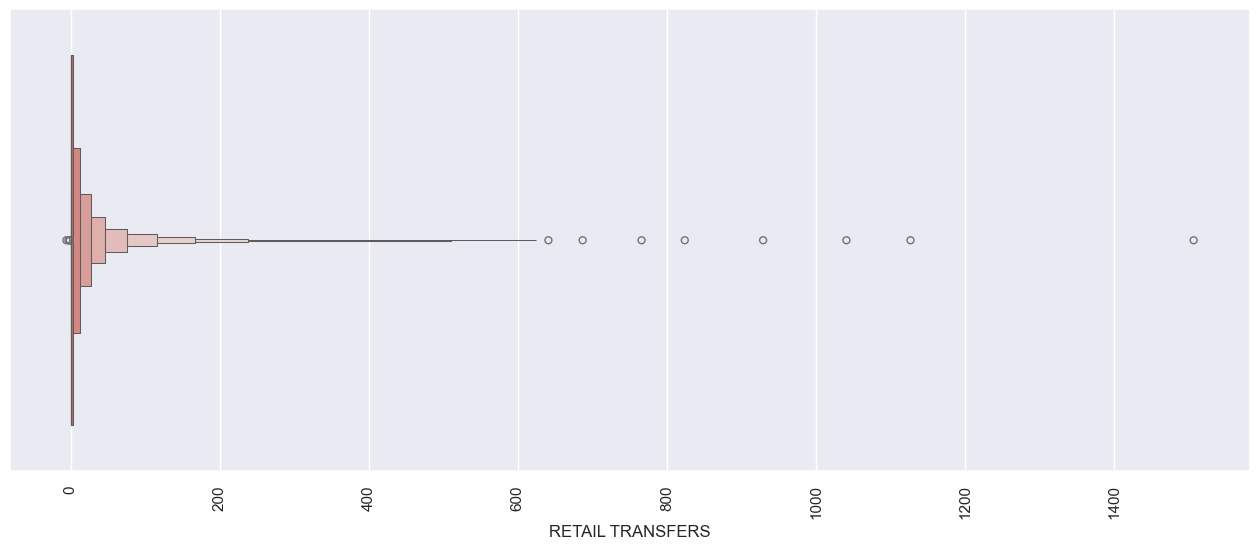

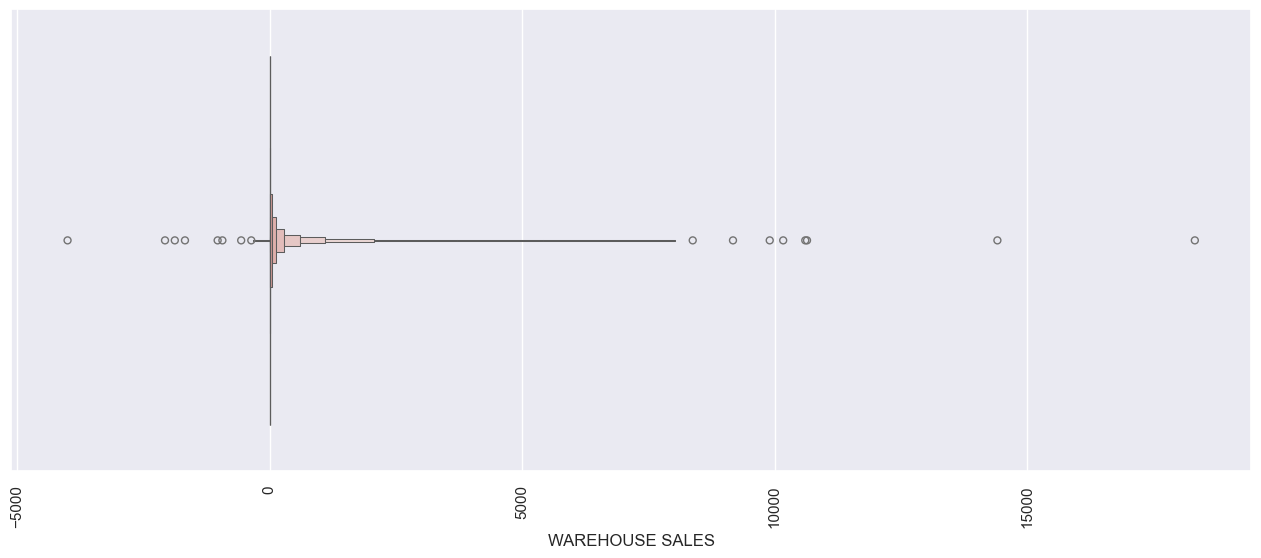

In [39]:
for i in continuous:
    plt.figure(figsize=(16,6))
    sns.boxenplot(x=i, data=df, palette='hls')
    plt.xticks(rotation = 90)
    plt.show()

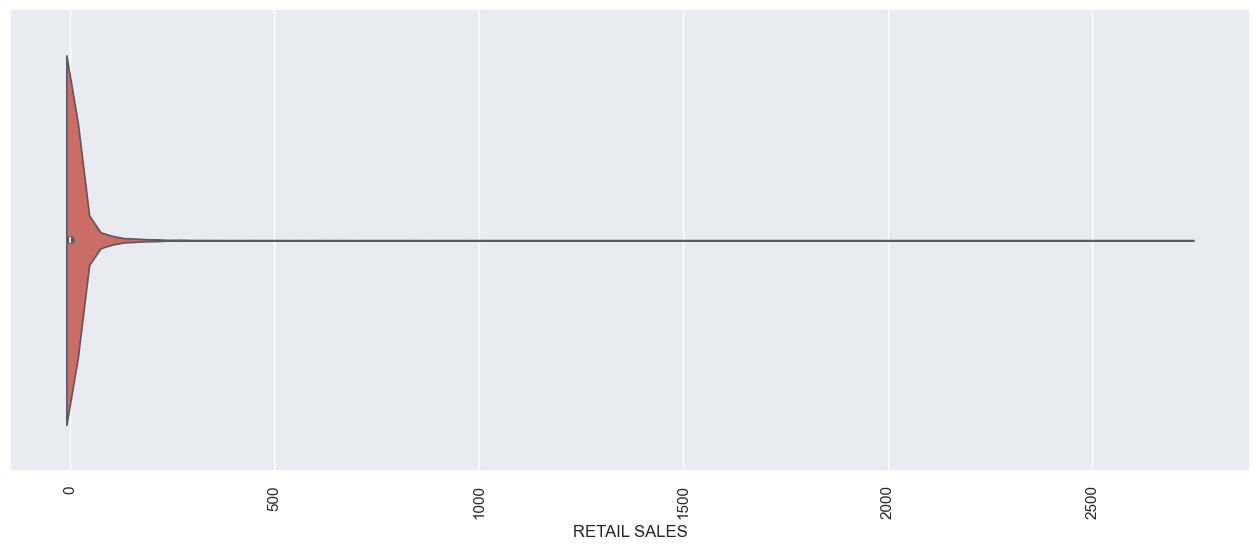

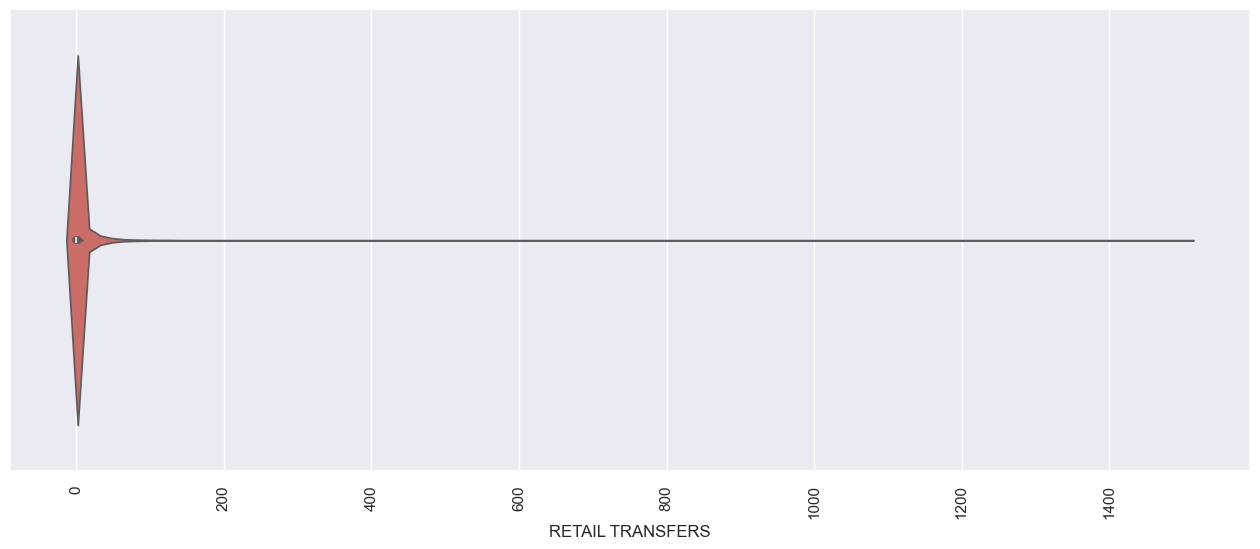

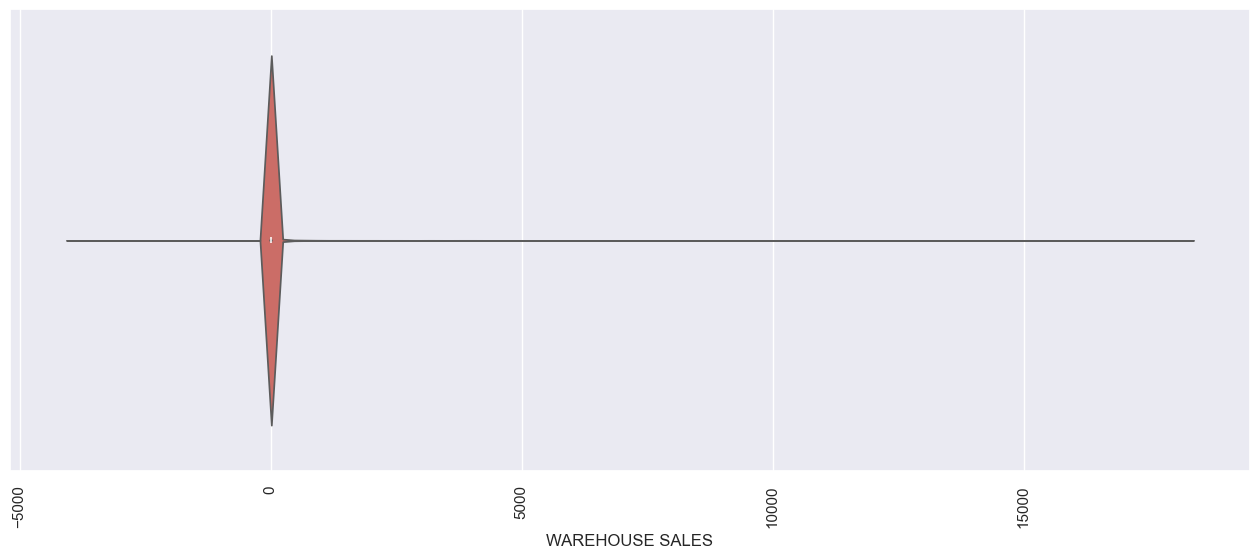

In [40]:
for i in continuous:
    plt.figure(figsize=(16,6))
    sns.violinplot(x=i, data=df, palette='hls')
    plt.xticks(rotation = 90)
    plt.show()

In [41]:
df['RETAIL SALES'].value_counts()

RETAIL SALES
0.00      13689
0.08        819
0.17        635
0.16        481
0.24        310
          ...  
0.31          1
51.75         1
36.45         1
24.86         1
329.04        1
Name: count, Length: 3657, dtype: int64

In [42]:
continuous

['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

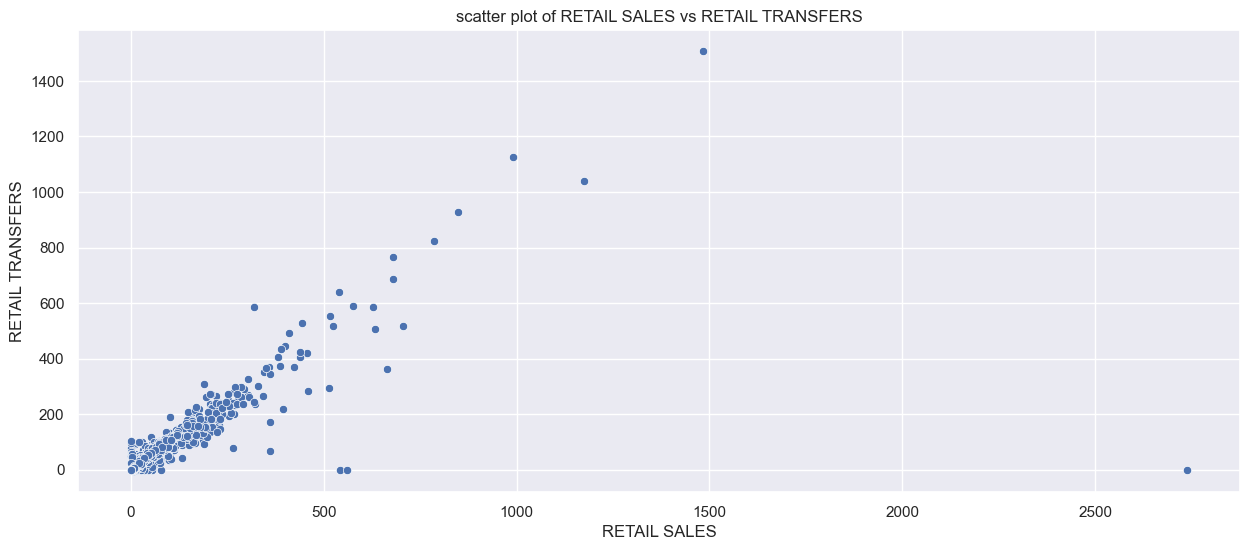

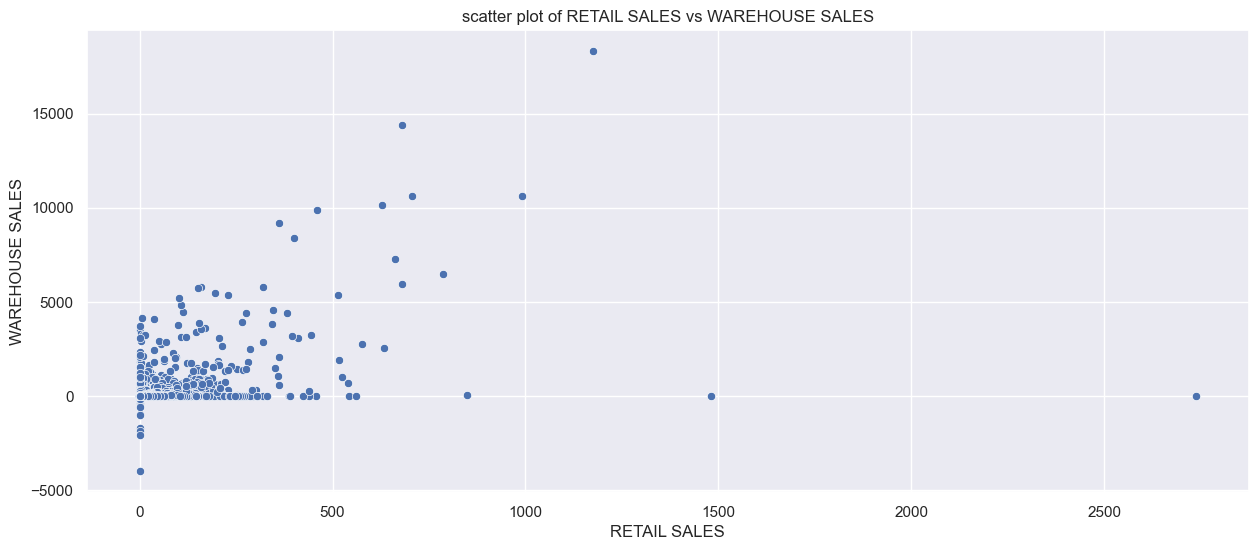

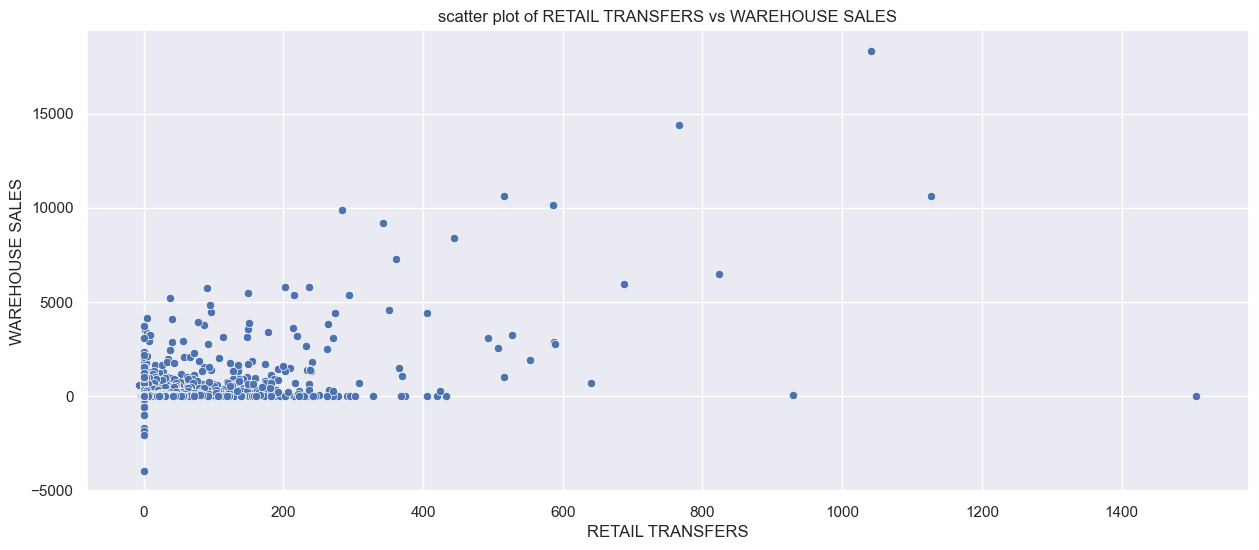

In [43]:
for i in range(len(continuous)):
    for j in range(i+1, len(continuous)):
        plt.figure(figsize=(15,6))
        sns.scatterplot(x=continuous[i], y=continuous[j], data=df, palette = 'hls')
        plt.title(f'scatter plot of {continuous[i]} vs {continuous[j]}')
        plt.show()

In [44]:
corr_matrix = df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].corr()
corr_matrix

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
RETAIL SALES,1.000000,0.844598,0.491823
RETAIL TRANSFERS,0.844598,1.000000,0.540071
WAREHOUSE SALES,0.491823,0.540071,1.000000


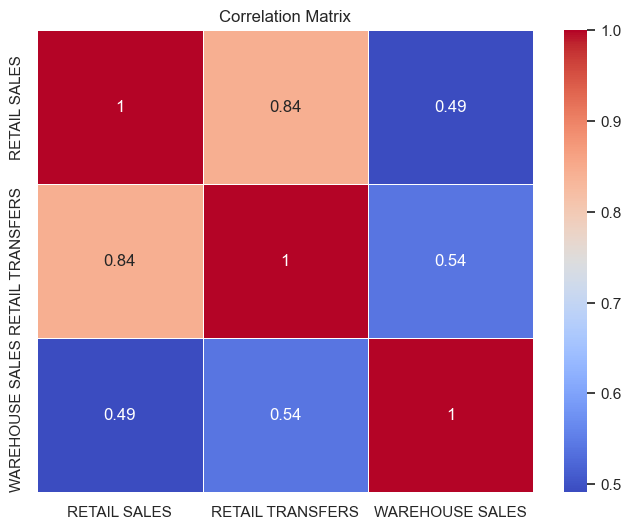

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [46]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [47]:
fig = px.scatter_3d(df, x='RETAIL SALES', y = 'RETAIL TRANSFERS', z='WAREHOUSE SALES', color='ITEM TYPE')
fig.update_layout(title='3D Scatter Plot of Sales Data', scene = dict(xaxis_title="Retail Sales", 
                                                                      yaxis_title="Retail Transfers",
                                                                      zaxis_title = "Warehouse sales"))
fig.show()

In [48]:
pivot_table = pd.pivot_table(df, values = 'RETAIL SALES', index = ['YEAR', 'MONTH'],
                             columns = ['ITEM TYPE'], aggfunc='sum', fill_value=0)

In [49]:
pivot_table

ITEM TYPE       BEER  DUNNAGE  KEGS    LIQUOR  NON-ALCOHOL    REF  \
YEAR MONTH                                                          
2020 1      18241.05        0     0  29345.39      1471.81  16.02   
     3      11742.04        0     0  14174.66       704.67  22.08   
     7      28907.53        0     0  35430.95      4527.73   8.17   
     9        648.14        0     0   2791.85       120.57   0.00   

ITEM TYPE   STR_SUPPLIES      WINE  
YEAR MONTH                          
2020 1            153.43  25091.07  
     3             78.53   7801.92  
     7             81.23  25583.51  
     9             32.41   1212.34

In [50]:
pivot_table = pd.pivot_table(df, values = 'RETAIL TRANSFERS', index = ['YEAR', 'MONTH'],
                             columns = ['ITEM TYPE'], aggfunc='sum', fill_value=0)
pivot_table

ITEM TYPE       BEER  DUNNAGE  KEGS    LIQUOR  NON-ALCOHOL  REF  STR_SUPPLIES  \
YEAR MONTH                                                                      
2020 1      20607.00        0     0  29330.81      1034.75   25           344   
     3      12051.00        0     0  14610.29       138.00    0            52   
     7      22576.83        0     0  32850.99      1665.00    9           487   
     9        495.00        0     0   2807.61        96.33    0            12   

ITEM TYPE       WINE  
YEAR MONTH            
2020 1      24655.79  
     3       7653.79  
     7      25117.75  
     9       1201.80

In [51]:
pivot_table = pd.pivot_table(df, values = ['RETAIL TRANSFERS','RETAIL SALES'], index = ['YEAR', 'MONTH'],
                             columns = ['ITEM TYPE'], aggfunc='sum', fill_value=0)
pivot_table

RETAIL SALES                                            \
ITEM TYPE          BEER DUNNAGE KEGS    LIQUOR NON-ALCOHOL    REF   
YEAR MONTH                                                          
2020 1         18241.05       0    0  29345.39     1471.81  16.02   
     3         11742.04       0    0  14174.66      704.67  22.08   
     7         28907.53       0    0  35430.95     4527.73   8.17   
     9           648.14       0    0   2791.85      120.57   0.00   

                                  RETAIL TRANSFERS                         \
ITEM TYPE  STR_SUPPLIES      WINE             BEER DUNNAGE KEGS    LIQUOR   
YEAR MONTH                                                                  
2020 1           153.43  25091.07         20607.00       0    0  29330.81   
     3            78.53   7801.92         12051.00       0    0  14610.29   
     7            81.23  25583.51         22576.83       0    0  32850.99   
     9            32.41   1212.34           495.00       0    0   2807.61   

                                                   
ITEM TYPE  NON-ALCOHOL REF STR_SUPPLIES      WINE  
YEAR MONTH                                         
2020 1         1034.75  25          344  24655.79  
     3          138.00   0           52   7653.79  
     7         1665.00   9          487  25117.75  
     9           96.33   0           12   1201.80

In [52]:
correlation_matrix = corr_matrix
correlation_matrix

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
RETAIL SALES,1.000000,0.844598,0.491823
RETAIL TRANSFERS,0.844598,1.000000,0.540071
WAREHOUSE SALES,0.491823,0.540071,1.000000


In [53]:
threshold = 0.80 # Business will provide you
highly_correlated_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            highly_correlated_features.add(colname)
            highly_correlated_features.add(correlation_matrix.columns[j])

In [54]:
highly_correlated_features

{'RETAIL SALES', 'RETAIL TRANSFERS'}

In [55]:
df = df.drop('RETAIL TRANSFERS', axis=1)
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES'],
      dtype='object')

In [56]:
df.head(3)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.0,1.0


In [57]:
df['ITEM DESCRIPTION'].nunique()

15732

In [58]:
df1 = df[['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES']]
df1.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,RETAIL SALES,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,WINE,0.00,2.0
1,2020,1,PWSWN INC,WINE,0.00,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,BEER,0.00,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,WINE,0.00,1.0
4,2020,1,DIONYSOS IMPORTS INC,WINE,0.82,0.0


# Linear Regression Algorithm

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [60]:
min_value = df1[['RETAIL SALES', 'WAREHOUSE SALES']].min().min()
constant = abs(min_value) + 1 if min_value <=0 else 0

In [61]:
constant

4000.0

In [62]:
df1['RETAIL SALES'].min()

-0.42

In [63]:
df1['RETAIL SALES'].max()

2739.0

In [64]:
df['Log_Retail_Sales'] = np.log1p(df1['RETAIL SALES'] + constant)
df['Log_WAREHOUSE_SALES'] = np.log1p(df['WAREHOUSE SALES'] + constant)

In [65]:
df['Log_Retail_Sales'].min()

8.294194629590544

In [66]:
df['Log_Retail_Sales'].max()

8.815815203906352

In [67]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES', 'Log_Retail_Sales',
       'Log_WAREHOUSE_SALES'],
      dtype='object')

In [68]:
x = df[['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'Log_WAREHOUSE_SALES']]
y = df['Log_Retail_Sales']

In [69]:
categorical_features = ['SUPPLIER', 'ITEM TYPE']
numerical_features = ['YEAR', 'MONTH', 'Log_WAREHOUSE_SALES']

In [70]:
preprocessor = ColumnTransformer(transformers = [('num', 'passthrough', numerical_features),
                                                 ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

In [71]:
preprocessor

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['YEAR', 'MONTH', 'Log_WAREHOUSE_SALES']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['SUPPLIER', 'ITEM TYPE'])])

linear = LinearRegression()
linear.fit(x_train, y_train)
y_pred_train = linear.predict(x_train)
y_pred_test = linear.predict(x_test)

In [72]:
pipeline = Pipeline(steps = [('preprocessor',preprocessor), ('regressor', LinearRegression())])

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [74]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['YEAR', 'MONTH',
                                                   'Log_WAREHOUSE_SALES']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SUPPLIER', 'ITEM TYPE'])])),
                ('regressor', LinearRegression())])

In [75]:
y_pred = pipeline.predict(x_test)

In [76]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error : {mse}')
print(f'R^2 Score : {r2}')

Mean Squared Error : 2.2956860452071727e-05
R^2 Score : 0.29261337212098726


# Different Regression model

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [78]:
df1 = df[['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES']]
x = df1[['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'WAREHOUSE SALES']]
y = df1['RETAIL SALES']

In [79]:
preprocessor = ColumnTransformer(transformers = [('cat', OneHotEncoder(handle_unknown='ignore'), ['SUPPLIER', 'ITEM TYPE']),
                                                 ('num', StandardScaler(), ['WAREHOUSE SALES'])])

In [80]:
models = {'SVR':SVR(),
          'Decision Tree': DecisionTreeRegressor(),
          'Random Forest': RandomForestRegressor(),
          'XGBoost':XGBRegressor(eval_metric='mae')}

In [81]:
from sklearn.metrics import mean_absolute_error, r2_score

In [82]:
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps = [('preprocessor',preprocessor), ('model', model)])
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'R2': r2}

In [83]:
results_df = pd.DataFrame(results).T
print(results_df)

                    MAE        R2
SVR            5.666667  0.121581
Decision Tree  6.246803  0.158638
Random Forest  5.863836  0.305956
XGBoost        5.714694  0.365457


# Regularization method

In [84]:
from sklearn.linear_model import Ridge

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), ('ridge', Ridge(alpha = 0.001))])
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SUPPLIER', 'ITEM TYPE']),
                                                 ('num', StandardScaler(),
                                                  ['WAREHOUSE SALES'])])),
                ('ridge', Ridge(alpha=0.001))])

In [85]:
y_pred = pipeline.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'mean squared error : {mse}')
print(f'R^2 Score : {r2}')

mean squared error : 398.0205255352094
R^2 Score : 0.2839261423451249


In [86]:
x_train.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,WAREHOUSE SALES
21753,2020,7,HEINEKEN USA,BEER,631.00
251,2020,1,DOPS INC,BEER,1.00
22941,2020,7,MILLER BREWING COMPANY,BEER,351.75
618,2020,1,"THE COUNTRY VINTNER, LLC DBA WINEBOW",WINE,1.00
17090,2020,7,INTERBALT PRODUCTS CORP,BEER,1.00


In [87]:
df1.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,RETAIL SALES,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,WINE,0.00,2.0
1,2020,1,PWSWN INC,WINE,0.00,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,BEER,0.00,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,WINE,0.00,1.0
4,2020,1,DIONYSOS IMPORTS INC,WINE,0.82,0.0


In [88]:
df2 = df1.copy()

In [89]:
df2['sales_ratio'] = df1['RETAIL SALES']/df1['WAREHOUSE SALES']
df2['sales_difference'] = df1['RETAIL SALES'] - df1['WAREHOUSE SALES']

In [90]:
df2['retail_sales_growth'] = df1['RETAIL SALES'].pct_change()
df2['warehouse_sales_growth'] = df1['WAREHOUSE SALES'].pct_change()

In [91]:
df2.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,RETAIL SALES,WAREHOUSE SALES,sales_ratio,sales_difference,retail_sales_growth,warehouse_sales_growth
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,WINE,0.00,2.0,0.0,-2.00,NaN,NaN
1,2020,1,PWSWN INC,WINE,0.00,4.0,0.0,-4.00,NaN,1.00
2,2020,1,RELIABLE CHURCHILL LLLP,BEER,0.00,1.0,0.0,-1.00,NaN,-0.75
3,2020,1,LANTERNA DISTRIBUTORS INC,WINE,0.00,1.0,0.0,-1.00,NaN,0.00
4,2020,1,DIONYSOS IMPORTS INC,WINE,0.82,0.0,inf,0.82,inf,-1.00


# Unsupervised Learning - PCA

In [92]:
from sklearn.decomposition import PCA

In [93]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES', 'Log_Retail_Sales',
       'Log_WAREHOUSE_SALES'],
      dtype='object')

In [94]:
df1 = df[['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES']]

In [95]:
preprocessor = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(), ['SUPPLIER', 'ITEM TYPE']),
    ('num', StandardScaler(), ['RETAIL SALES', 'WAREHOUSE SALES'])    
])

In [96]:
preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                 ['SUPPLIER', 'ITEM TYPE']),
                                ('num', StandardScaler(),
                                 ['RETAIL SALES', 'WAREHOUSE SALES'])])

In [97]:
pipeline = Pipeline(steps = [('preprocessor', preprocessor)])
x_processed = pipeline.fit_transform(df1)
x_processed

<30000x301 sparse matrix of type '<class 'numpy.float64'>'
	with 120000 stored elements in Compressed Sparse Row format>

In [98]:
inertia = []
K_range = range(1,11)

In [99]:
from sklearn.cluster import KMeans

In [100]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_processed)
    inertia.append(kmeans.inertia_)

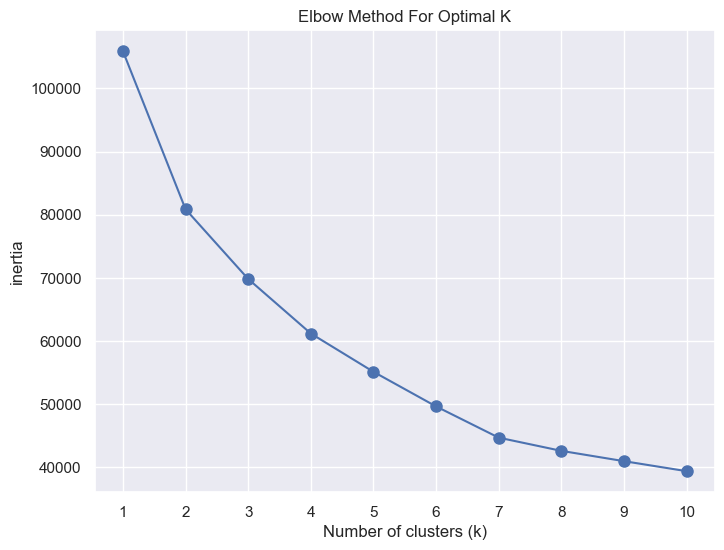

In [101]:
plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Number of clusters (k)")
plt.ylabel("inertia")
plt.title("Elbow Method For Optimal K")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [102]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(x_processed)
clusters

array([1, 1, 0, ..., 1, 3, 1])

In [103]:
df1['Cluster'] = clusters
df1.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,RETAIL SALES,WAREHOUSE SALES,Cluster
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,WINE,0.00,2.0,1
1,2020,1,PWSWN INC,WINE,0.00,4.0,1
2,2020,1,RELIABLE CHURCHILL LLLP,BEER,0.00,1.0,0
3,2020,1,LANTERNA DISTRIBUTORS INC,WINE,0.00,1.0,1
4,2020,1,DIONYSOS IMPORTS INC,WINE,0.82,0.0,1


In [104]:
df1['Cluster'].unique()

array([1, 0, 3, 2])

In [105]:
df1['Cluster'].value_counts()

Cluster
1    18659
0    11014
3      306
2       21
Name: count, dtype: int64

In [106]:
from scipy.sparse import csr_matrix

In [107]:
if isinstance(x_processed, csr_matrix):
    x_processed = x_processed.toarray()
x_processed
    

array([[ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.2097816 , -0.09344094],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.2097816 , -0.08609236],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.2097816 , -0.09711523],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.2097816 , -0.07874379],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         9.73702179, -0.10078952],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.2097816 , -0.09711523]])

In [108]:
x_processed_df = pd.DataFrame(x_processed)
x_processed_df.head()

,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,300
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.093441
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.086092
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.209782,-0.097115
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.097115
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.184993,-0.100790


In [109]:
x_processed_df.shape

(30000, 301)

In [110]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_processed)

In [111]:
x_pca

array([[-0.25908542, -0.15275649],
       [-0.24707984, -0.14966195],
       [-0.12679972, -0.09084188],
       ...,
       [-0.24247716, -0.15403929],
       [ 6.83566026,  6.96108227],
       [-0.26384091, -0.15723661]])

In [112]:
df_pca = pd.DataFrame(x_pca, columns = ['PCA1', 'PCA2'])
df_pca['Cluster'] = clusters
df_pca

,PCA1,PCA2,Cluster
0,-0.259085,-0.152756,1
1,-0.247080,-0.149662,1
2,-0.126800,-0.090842,0
3,-0.254907,-0.141662,1
4,-0.240364,-0.122854,1
...,...,...,...
29995,-0.170373,0.120237,0
29996,-0.255747,-0.136479,1
29997,-0.242477,-0.154039,1
29998,6.835660,6.961082,3


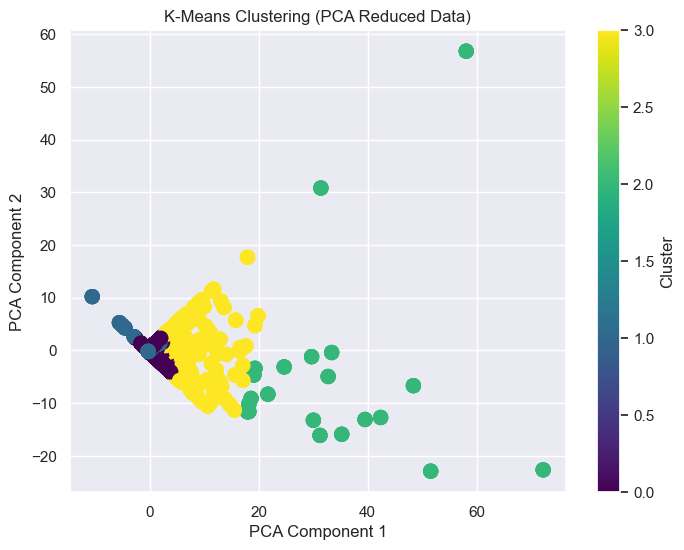

In [113]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c = clusters, cmap='viridis', s=100)
plt.scatter(x_pca[:,0], x_pca[:,1], c = clusters, cmap='viridis', s=100)
plt.scatter(x_pca[:,0], x_pca[:,1], c = clusters, cmap='viridis', s=100)
plt.scatter(x_pca[:,0], x_pca[:,1], c = clusters, cmap='viridis', s=100)
plt.title("K-Means Clustering (PCA Reduced Data)")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

# Recommendation system - 

# Association Rule Mining (Market Basket Analytics) - Support , Confidence, Lift

In [114]:
df1['ITEM TYPE'].value_counts()

ITEM TYPE
WINE            18680
LIQUOR           5995
BEER             4217
KEGS              808
NON-ALCOHOL       216
STR_SUPPLIES       63
DUNNAGE            13
REF                 8
Name: count, dtype: int64

In [115]:
df1.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'RETAIL SALES',
       'WAREHOUSE SALES', 'Cluster'],
      dtype='object')

In [118]:
from mlxtend.frequent_patterns import association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder

In [119]:
basket = df1.groupby(['SUPPLIER','YEAR', 'MONTH'])['ITEM TYPE'].apply(list).reset_index()
basket

,SUPPLIER,YEAR,MONTH,ITEM TYPE
0,A I G WINE & SPIRITS,2020,1,"[WINE, WINE, WINE]"
1,A I G WINE & SPIRITS,2020,3,"[WINE, WINE, WINE]"
2,A I G WINE & SPIRITS,2020,7,"[WINE, WINE, WINE]"
3,ADAMBA IMPORTS INTL,2020,1,[LIQUOR]
4,ADAMBA IMPORTS INTL,2020,7,[LIQUOR]
...,...,...,...,...
913,YUENGLING BREWERY,2020,7,"[BEER, BEER, BEER, BEER, BEER, BEER, BEER, BEE..."
914,Z WINE GALLERY IMPORTS LLC,2020,7,[WINE]
915,ZURENA LLC,2020,1,[NON-ALCOHOL]
916,ZURENA LLC,2020,3,[NON-ALCOHOL]


In [120]:
te = TransactionEncoder()
te_ary = te.fit(basket['ITEM TYPE']).transform(basket['ITEM TYPE'])
basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)
basket_encoded

,BEER,DUNNAGE,KEGS,LIQUOR,NON-ALCOHOL,REF,STR_SUPPLIES,WINE
0,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,True
3,False,False,False,True,False,False,False,False
4,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...
913,True,False,True,False,False,False,False,False
914,False,False,False,False,False,False,False,True
915,False,False,False,False,True,False,False,False
916,False,False,False,False,True,False,False,False


In [121]:
frequent_itemsets = apriori(basket_encoded, min_support=0.01, use_colnames=True)

In [122]:
frequent_itemsets

,support,itemsets
0,0.257081,(BEER)
1,0.010893,(DUNNAGE)
2,0.136166,(KEGS)
3,0.315904,(LIQUOR)
4,0.053377,(NON-ALCOHOL)
5,0.013072,(STR_SUPPLIES)
6,0.639434,(WINE)
7,0.130719,"(BEER, KEGS)"
8,0.061002,"(BEER, LIQUOR)"
9,0.023965,"(BEER, NON-ALCOHOL)"


In [123]:
rules = association_rules(frequent_itemsets, metric = 'lift', min_threshold=2)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(BEER),(KEGS),0.257081,0.136166,0.130719,0.508475,3.734237,1.0,0.095713,1.757456,0.985582,0.497925,0.430996,0.734237
1,(KEGS),(BEER),0.136166,0.257081,0.130719,0.960000,3.734237,1.0,0.095713,18.572985,0.847625,0.497925,0.946158,0.734237
2,(NON-ALCOHOL),(KEGS),0.053377,0.136166,0.017429,0.326531,2.398041,1.0,0.010161,1.282663,0.615866,0.101266,0.220372,0.227265
3,(KEGS),(NON-ALCOHOL),0.136166,0.053377,0.017429,0.128000,2.398041,1.0,0.010161,1.085577,0.674890,0.101266,0.078831,0.227265
4,"(BEER, LIQUOR)",(KEGS),0.061002,0.136166,0.021786,0.357143,2.622857,1.0,0.013480,1.343742,0.658933,0.124224,0.255810,0.258571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,"(NON-ALCOHOL, WINE)","(BEER, LIQUOR)",0.023965,0.061002,0.015251,0.636364,10.431818,1.0,0.013789,2.582244,0.926339,0.218750,0.612740,0.443182
70,"(LIQUOR, WINE)","(BEER, NON-ALCOHOL)",0.166667,0.023965,0.015251,0.091503,3.818182,1.0,0.011256,1.074341,0.885714,0.086957,0.069196,0.363933
71,(BEER),"(NON-ALCOHOL, LIQUOR, WINE)",0.257081,0.022876,0.015251,0.059322,2.593220,1.0,0.009370,1.038745,0.826979,0.057613,0.037299,0.362994
72,(NON-ALCOHOL),"(BEER, LIQUOR, WINE)",0.053377,0.053377,0.015251,0.285714,5.352770,1.0,0.012401,1.325272,0.859033,0.166667,0.245438,0.285714


In [124]:
rules.sort_values(by='lift', ascending=False, inplace=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
47,"(KEGS, LIQUOR)","(BEER, NON-ALCOHOL)",0.021786,0.023965,0.010893,0.500000,20.863636,1.0,0.010371,1.952070,0.973274,0.312500,0.487723,0.477273
44,"(BEER, NON-ALCOHOL)","(KEGS, LIQUOR)",0.023965,0.021786,0.010893,0.454545,20.863636,1.0,0.010371,1.793391,0.975446,0.312500,0.442397,0.477273
55,"(BEER, LIQUOR)","(KEGS, WINE)",0.061002,0.019608,0.015251,0.250000,12.750000,1.0,0.014054,1.307190,0.981439,0.233333,0.235000,0.513889
58,"(KEGS, WINE)","(BEER, LIQUOR)",0.019608,0.061002,0.015251,0.777778,12.750000,1.0,0.014054,4.225490,0.940000,0.233333,0.763341,0.513889
66,"(BEER, LIQUOR)","(NON-ALCOHOL, WINE)",0.061002,0.023965,0.015251,0.250000,10.431818,1.0,0.013789,1.301380,0.962877,0.218750,0.231585,0.443182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,(BEER),"(NON-ALCOHOL, LIQUOR)",0.257081,0.031590,0.017429,0.067797,2.146113,1.0,0.009308,1.038839,0.718842,0.064257,0.037387,0.309760
60,(KEGS),"(BEER, LIQUOR, WINE)",0.136166,0.053377,0.015251,0.112000,2.098286,1.0,0.007982,1.066017,0.605927,0.087500,0.061929,0.198857
53,"(BEER, LIQUOR, WINE)",(KEGS),0.053377,0.136166,0.015251,0.285714,2.098286,1.0,0.007982,1.209368,0.552934,0.087500,0.173122,0.198857
14,"(BEER, WINE)",(KEGS),0.071895,0.136166,0.019608,0.272727,2.002909,1.0,0.009818,1.187772,0.539515,0.104046,0.158088,0.208364


In [125]:
rules.to_csv("rules.csv")

# MultiLayer Perceptron / Artificial Neural Network / Deep Neural Network

In [126]:
# !pip install tensorflow
# !pip install keras
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential 
from keras.optimizers import Adam
from keras.layers import *

C:\Users\soura\anaconda3\envs\tfstable\lib\site-packages\tensorflow\python\framework\dtypes.py:246: DeprecationWarning:

`np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)

C:\Users\soura\anaconda3\envs\tfstable\lib\site-packages\tensorboard\compat\tensorflow_stub\dtypes.py:326: DeprecationWarning:

`np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)



In [127]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES', 'Log_Retail_Sales',
       'Log_WAREHOUSE_SALES'],
      dtype='object')

In [128]:
df1 = df[['YEAR', 'MONTH', 'SUPPLIER','ITEM TYPE', 'RETAIL SALES', 'WAREHOUSE SALES']]
categorical_features = ['SUPPLIER','ITEM TYPE']
numerical_features = ['YEAR', 'MONTH','RETAIL SALES', 'WAREHOUSE SALES']

In [129]:
# This is mandatory steps in DNN
# Numerical variable - feature scaling

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), categorical_features),
    ('num', StandardScaler(),numerical_features)
])

In [130]:
x = df1.drop(columns=['RETAIL SALES'])
y = df1['RETAIL SALES']

In [131]:
x.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM TYPE', 'WAREHOUSE SALES'], dtype='object')

In [132]:
x.head()

,YEAR,MONTH,SUPPLIER,ITEM TYPE,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,WINE,2.0
1,2020,1,PWSWN INC,WINE,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,BEER,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,WINE,1.0
4,2020,1,DIONYSOS IMPORTS INC,WINE,0.0


In [133]:
y.head()

0    0.00
1    0.00
2    0.00
3    0.00
4    0.82
Name: RETAIL SALES, dtype: float64

In [134]:
pd.DataFrame(x_processed).shape

(30000, 301)

In [135]:
y.shape

(30000,)

In [136]:
pd.DataFrame(x_processed).head()

,0,1,2,3,4,5,6,7,8,9,...,291,292,293,294,295,296,297,298,299,300
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.093441
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.086092
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.209782,-0.097115
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.209782,-0.097115
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.184993,-0.100790


In [137]:
x_train, x_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, random_state=42)

In [138]:
# Building Deep Neural Network

model = Sequential()
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/100
750/750 [==============================] - 3s 4ms/step - loss: 686.1004 - mae: 3.7066 - val_loss: 20.5344 - val_mae: 0.5357
Epoch 2/100
750/750 [==============================] - 2s 3ms/step - loss: 55.5519 - mae: 0.5493 - val_loss: 0.7125 - val_mae: 0.2031
Epoch 3/100
750/750 [==============================] - 3s 3ms/step - loss: 8.4855 - mae: 0.4308 - val_loss: 0.0881 - val_mae: 0.1561
Epoch 4/100
750/750 [==============================] - 3s 4ms/step - loss: 1.6624 - mae: 0.3920 - val_loss: 0.5720 - val_mae: 0.2561
Epoch 5/100
750/750 [==============================] - 3s 4ms/step - loss: 0.1716 - mae: 0.1778 - val_loss: 0.0998 - val_mae: 0.1521
Epoch 6/100
750/750 [==============================] - 3s 3ms/step - loss: 0.6482 - mae: 0.2645 - val_loss: 0.0997 - val_mae: 0.1557
Epoch 7/100
750/750 [==============================] - 3s 4ms/step - loss: 0.3369 - mae: 0.2262 - val_loss: 0.0762 - val_mae: 0.1312
Epoch 8/100
750/750 [==============================] - 3s 4ms/ste

750/750 [==============================] - 2s 3ms/step - loss: 0.4628 - mae: 0.2158 - val_loss: 0.0171 - val_mae: 0.0461
Epoch 63/100
750/750 [==============================] - 3s 3ms/step - loss: 5.2247 - mae: 0.3690 - val_loss: 0.3074 - val_mae: 0.3987
Epoch 64/100
750/750 [==============================] - 2s 3ms/step - loss: 1.7409 - mae: 0.2221 - val_loss: 0.0126 - val_mae: 0.0488
Epoch 65/100
750/750 [==============================] - 2s 3ms/step - loss: 0.2805 - mae: 0.1530 - val_loss: 0.0204 - val_mae: 0.0889
Epoch 66/100
750/750 [==============================] - 3s 4ms/step - loss: 0.0211 - mae: 0.0530 - val_loss: 0.4748 - val_mae: 0.3044
Epoch 67/100
750/750 [==============================] - 2s 3ms/step - loss: 1.4311 - mae: 0.3620 - val_loss: 0.2165 - val_mae: 0.1287
Epoch 68/100
750/750 [==============================] - 3s 4ms/step - loss: 0.7572 - mae: 0.2320 - val_loss: 0.9373 - val_mae: 0.6590
Epoch 69/100
750/750 [==============================] - 3s 4ms/step - loss:

In [139]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                19328     
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 21,441
Trainable params: 21,441
Non-trainable params: 0
_________________________________________________________________


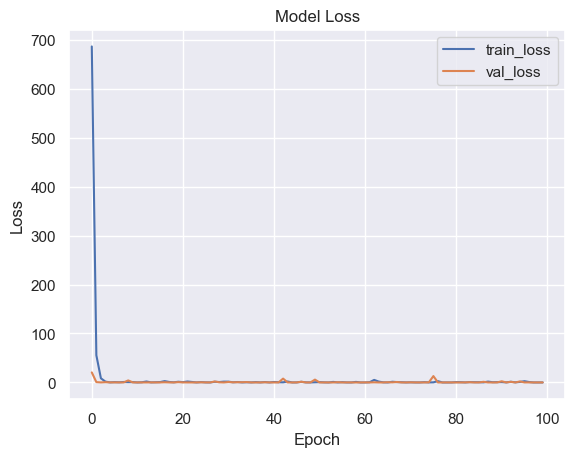

In [140]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

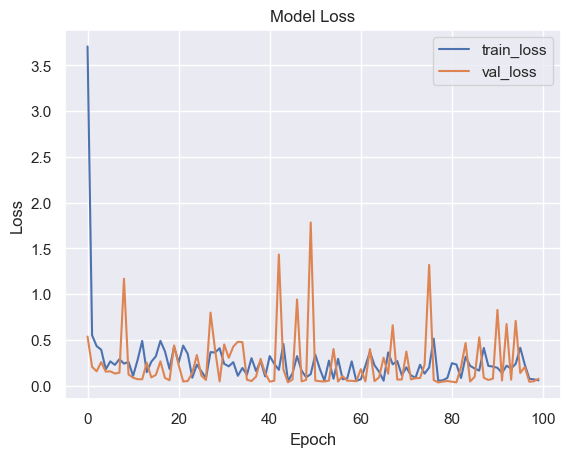

In [141]:
plt.plot(history.history['mae'], label='train_loss')
plt.plot(history.history['val_mae'], label='val_loss')
plt.title('Model Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [142]:
loss, mae = model.evaluate(x_test, y_test)
print(f"Test Loss : {loss}")
print(f"Mean Absolute Error : {mae}")

188/188 [==============================] - 1s 3ms/step - loss: 0.0206 - mae: 0.0744
Test Loss : 0.0206392053514719
Mean Absolute Error : 0.07436517626047134
